# POD vector space tutorial

In this tutorial you will learn:
- How to construct a vector space using proper orthogonal decomposition
- How to use a truncater

In [1]:
#First, let's import the relavant modules:
import romtools
import numpy as np
from matplotlib import pyplot as plt
from romtools import vector_space

In [2]:
#Now, we will load in snapshots from a FOM. Here, we use pre-computed snapshots of the 1D Euler equations obtained using pressio-demo-apps
snapshots = np.load('snapshots.npz')['snapshots']

## The snapshots are in tensor form:
n_vars, nx, nt = snapshots.shape
## Note that romtools works with tensor forms (https://pressio.github.io/rom-tools-and-workflows/romtools/vector_space.html)

In [3]:
#Now, let's make a basis using POD that uses the first vector as an affine offset
#First, let's create a "shifter" that is responsible for shifting snapshots
#(https://pressio.github.io/rom-tools-and-workflows/romtools/vector_space/utils/shifter.html)
my_shifter = vector_space.utils.create_firstvec_shifter(snapshots)

#Now, let's create a truncater that controls for how we want to truncate our basis.
#(https://pressio.github.io/rom-tools-and-workflows/romtools/vector_space/utils/truncater.html)
#Let's use an energy-based criterion
my_truncater = vector_space.utils.EnergyBasedTruncater(0.999)

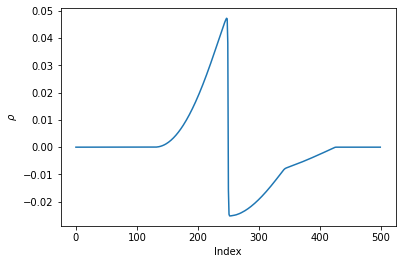

In [4]:
#Now, let's construct an affine vector space using POD with our shifter and truncater
#Note we don't use the first snapshot in the vector space since this is the affine offset
my_affine_vector_space = vector_space.VectorSpaceFromPOD(snapshots[...,1::],truncater=my_truncater,shifter=my_shifter)

##It's important to note that we do not do a deep copy of the snapshot matrix for performance reasons.
##Once you pass us the snapshot tensor, we will modify the data in place. 

#We can view the basis and shift vector:
basis = my_affine_vector_space.get_basis()
shift_vector = my_affine_vector_space.get_shift_vector()

#We can look at the density compoenent of the first basis:
plt.plot(basis[0,:,0])
plt.xlabel(r'Index')
plt.ylabel(r'$\rho$')
plt.show()

In [5]:
# We can check the dimension of the vector space
print("The dimension of the vector space is " , my_affine_vector_space.extents())
print("The number of basis vectors in my vector space is " , my_affine_vector_space.extents()[-1])

The dimension of the vector space is  (3, 500, 30)
The number of basis vectors in my vector space is  30


In [6]:
# We can also check that the basis is orthonormal:
is_identity = np.einsum('ijk,ijl->kl',basis,basis)
assert(np.allclose(is_identity,np.eye(30)))

[[ 1.00000000e+00 -6.49820039e-17 -2.87199184e-17  6.85538238e-17
   1.08505275e-16  1.95069006e-17  1.68902496e-16  1.19809607e-18
  -8.49965602e-17 -1.35652747e-16  7.06651399e-17 -3.11734825e-17
  -1.28614626e-16 -4.65911308e-17  6.15458372e-17  1.06960322e-16
   3.94451646e-17 -4.07487376e-17  4.91822635e-18  5.29379883e-17
  -1.58658207e-17 -2.28207207e-17 -1.05508567e-17  6.66130411e-17
  -4.16235026e-17  5.99126604e-17 -5.90871055e-17  1.84652423e-18
   2.36684114e-17 -6.72750163e-17]
 [-6.49820039e-17  1.00000000e+00 -5.60866181e-16 -9.59260028e-17
  -1.52515404e-16 -1.12770029e-16  2.03827269e-16  4.31244801e-17
  -7.77906188e-17  9.91707660e-19 -1.68957895e-17  1.17843770e-17
  -1.28907043e-16  2.66338191e-16  5.32013518e-17 -2.92028597e-17
  -6.01981907e-18  1.07763556e-16 -5.05359143e-17  1.07416362e-16
  -7.01634619e-17  4.83689401e-17 -1.57560013e-17  3.53855266e-17
   7.36274177e-18 -7.61831655e-17 -8.34256387e-18 -9.50992319e-17
   4.92787895e-17  6.90814993e-17]
 [-2.8